# Koduppgift 8 - Kapitel 8: CNN med CIFAR-100

I denna uppgift arbetar vi med CIFAR-100 datasetet som gicks igenom i kodexempel 1.

**Uppgiften består av tre delar:**

a) Skapa en CNN-modell för att prediktera datasetet.

b) Om du justerar hyperparametrar med KerasTuner, får du bättre resultat?

c) Prova använd transfer learning för att genomföra prediktioner, får du bättre resultat?

Mer information om CIFAR-100: https://www.cs.toronto.edu/~kriz/cifar.html

## Importera bibliotek

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, 
    Dropout, Dense
)
from tensorflow.keras.applications import MobileNetV2, ResNet50
import keras_tuner as kt
import os
import tempfile

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.19.1
Keras version: 3.11.3


# Del A: Skapa en CNN-modell för att prediktera datasetet

## Ladda och förbereda data

In [ ]:
# Ladda CIFAR-100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

# För demonstration: begränsa datasetet för snabbare träning
# Ta bort denna begränsning för bättre resultat
limit = 5000
x_train = x_train[:limit]
y_train = y_train[:limit]
x_test = x_test[:limit]
y_test = y_test[:limit]

# Normalisera pixlar till intervallet [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

# Kontrollera dimensioner
print(f"Träningsdata shape: {x_train.shape}")
print(f"Träningslabels shape: {y_train.shape}")
print(f"Testdata shape: {x_test.shape}")
print(f"Testlabels shape: {y_test.shape}")
print(f"\nCIFAR-100 har 100 klasser.")
print(f"Varje bild är 32x32 pixlar med 3 kanaler (RGB).")

Träningsdata shape: (5000, 32, 32, 3)
Träningslabels shape: (5000, 1)
Testdata shape: (5000, 32, 32, 3)
Testlabels shape: (5000, 1)

CIFAR-100 har 100 klasser.
Varje bild är 32x32 pixlar med 3 kanaler (RGB).


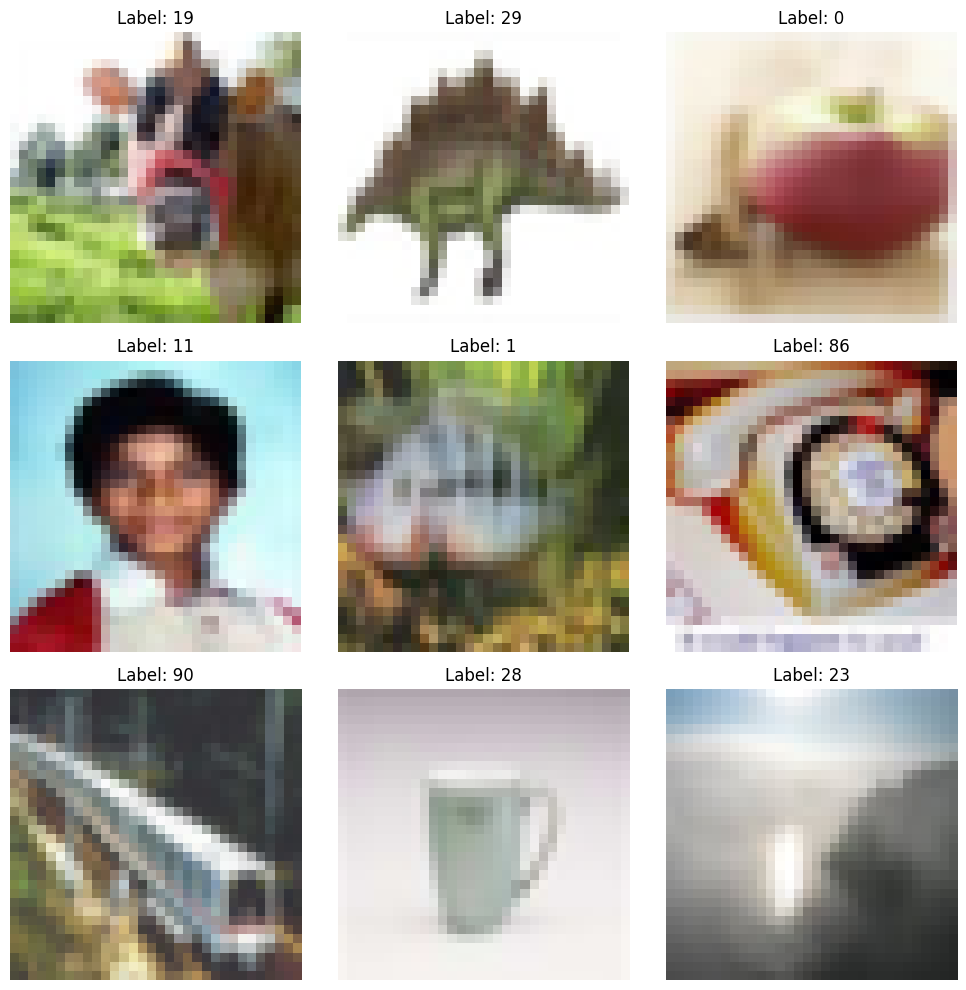

In [ ]:
# Visualisera några bilder från datasetet
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.axis('off')
    plt.title(f'Label: {y_train[i][0]}')
plt.tight_layout()

# Visa figuren
plt.show()

## Bygg CNN-modell

Vi bygger en CNN-modell 

In [ ]:
# Skapa CNN-modell med 4 convolutional block, flatten, dropout och 2 dense-lager för klassificering.
model_a = Sequential()

# Input layer
model_a.add(Input(shape=(32, 32, 3)))

# Convolutional layers med MaxPooling
# Conv2D-lager: Detekterar mönster (kanter, former, texturer).
# MaxPooling: Minskar datastorleken och extraherar viktiga features.
# Första blocket: 32 filter
model_a.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
model_a.add(MaxPooling2D(pool_size=(2, 2)))

# Andra blocket: 64 filter
model_a.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
model_a.add(MaxPooling2D(pool_size=(2, 2)))

# Tredje blocket: 128 filter
model_a.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model_a.add(MaxPooling2D(pool_size=(2, 2)))

# Fjärde blocket: 256 filter
model_a.add(Conv2D(256, kernel_size=(3, 3), padding='same', activation='relu'))
model_a.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten och Dense layers
# FLATTEN: Konverterar 2D-data till 1D
# Detta behövs för Dense layers som kräver 1D-input
model_a.add(Flatten())
model_a.add(Dropout(0.5))  # Regularisering
model_a.add(Dense(512, activation='relu'))
model_a.add(Dense(100, activation='softmax'))  # 100 klasser

# Visa modellstruktur
model_a.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 964,516 (3.68 MB)

 Trainable params: 964,516 (3.68 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Kompilera modellen
model_a.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Träna modellen
history_a = model_a.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

Epoch 1/10
32/32 - 3s - 92ms/step - accuracy: 0.0090 - loss: 4.6087 - val_accuracy: 0.0220 - val_loss: 4.5949
Epoch 2/10
32/32 - 1s - 36ms/step - accuracy: 0.0250 - loss: 4.4946 - val_accuracy: 0.0320 - val_loss: 4.3674
Epoch 3/10
32/32 - 1s - 28ms/step - accuracy: 0.0365 - loss: 4.3360 - val_accuracy: 0.0410 - val_loss: 4.2828
Epoch 4/10
32/32 - 1s - 29ms/step - accuracy: 0.0455 - loss: 4.1919 - val_accuracy: 0.0490 - val_loss: 4.2002
Epoch 5/10
32/32 - 1s - 45ms/step - accuracy: 0.0608 - loss: 4.0764 - val_accuracy: 0.0540 - val_loss: 4.1233
Epoch 6/10
32/32 - 1s - 47ms/step - accuracy: 0.0798 - loss: 3.9532 - val_accuracy: 0.0820 - val_loss: 4.0770
Epoch 7/10
32/32 - 1s - 33ms/step - accuracy: 0.1013 - loss: 3.8199 - val_accuracy: 0.0900 - val_loss: 3.9553
Epoch 8/10
32/32 - 1s - 29ms/step - accuracy: 0.1293 - loss: 3.6727 - val_accuracy: 0.1030 - val_loss: 3.8982
Epoch 9/10
32/32 - 1s - 28ms/step - accuracy: 0.1478 - loss: 3.5368 - val_accuracy: 0.1180 - val_loss: 3.8053
Epoch 10/1

157/157 - 1s - 9ms/step

Accuracy på testdata (Del A): 0.1444


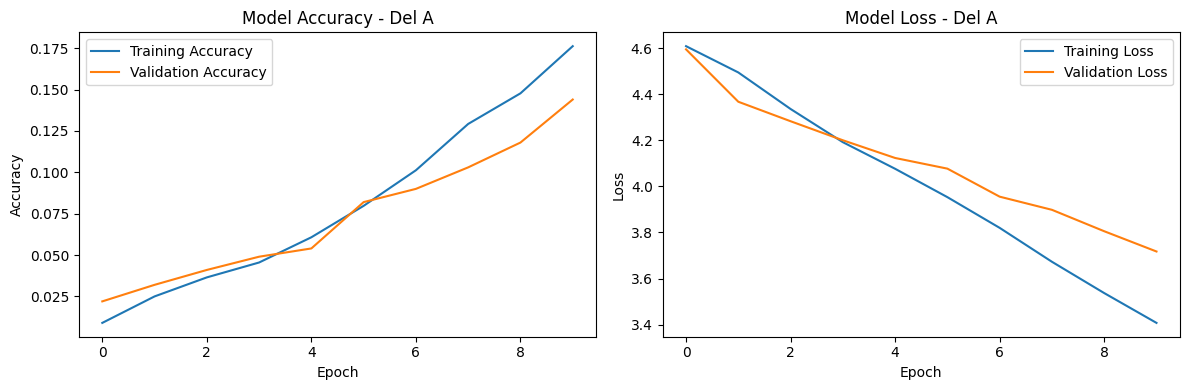

In [6]:
# Utvärdera modellen på testdata
y_pred_a = model_a.predict(x_test, verbose=2)
y_pred_labels_a = np.argmax(y_pred_a, axis=1)
accuracy_a = np.mean(y_pred_labels_a == y_test.flatten())

print(f"\nAccuracy på testdata (Del A): {accuracy_a:.4f}")

# Visualisera träningshistorik
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_a.history['accuracy'], label='Training Accuracy')
plt.plot(history_a.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy - Del A')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_a.history['loss'], label='Training Loss')
plt.plot(history_a.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss - Del A')
plt.legend()

plt.tight_layout()
plt.show()

# Del B: Justera hyperparametrar med KerasTuner

Vi använder KerasTuner för att automatiskt hitta bästa hyperparametrarna för vår CNN-modell.

In [7]:
# Definiera funktion som bygger modell med hyperparametrar från tuner
def build_model_cnn(hp):
    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))
    
    # Första Conv2D blocket - antal filter kan variera
    filters_1 = hp.Int('filters_1', min_value=16, max_value=64, step=16)
    model.add(Conv2D(filters_1, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Andra Conv2D blocket
    filters_2 = hp.Int('filters_2', min_value=32, max_value=128, step=32)
    model.add(Conv2D(filters_2, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Tredje Conv2D blocket
    filters_3 = hp.Int('filters_3', min_value=64, max_value=256, step=64)
    model.add(Conv2D(filters_3, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Fjärde Conv2D blocket
    filters_4 = hp.Int('filters_4', min_value=128, max_value=512, step=128)
    model.add(Conv2D(filters_4, kernel_size=(3, 3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    
    # Flatten och Dense layers
    model.add(Flatten())
    
    # Dropout rate kan variera
    dropout_rate = hp.Float('dropout_rate', min_value=0.3, max_value=0.7, step=0.1)
    model.add(Dropout(dropout_rate))
    
    # Antal neuroner i Dense layer kan variera
    dense_units = hp.Int('dense_units', min_value=256, max_value=1024, step=256)
    model.add(Dense(dense_units, activation='relu'))
    
    # Output layer
    model.add(Dense(100, activation='softmax'))
    
    # Learning rate kan variera
    learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4, 5e-5])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

print("Model builder-funktion definierad!")

Model builder-funktion definierad!


In [8]:
# Skapa RandomSearch tuner
tuner_dir = os.path.join(tempfile.gettempdir(), 'keras_tuner_cifar100')
os.makedirs(tuner_dir, exist_ok=True)

max_trials = 10  # Antal modellkonfigurationer att testa
# Öka max_trials för bättre resultat, men det tar längre tid

tuner = kt.RandomSearch(
    build_model_cnn,
    objective='val_accuracy',  # Maximera validation accuracy
    max_trials=max_trials,
    executions_per_trial=1,
    directory=tuner_dir,
    project_name='cifar100_cnn_optimization',
    overwrite=True
)

print(f"KerasTuner skapad! Kommer testa {max_trials} olika konfigurationer.")

KerasTuner skapad! Kommer testa 10 olika konfigurationer.


In [9]:
# Kör hyperparameter search
# Detta kan ta en stund beroende på max_trials och antal epoker
tuner.search(
    x_train, y_train,
    epochs=5,  # Färre epoker för snabbare sökning
    validation_split=0.2,
    batch_size=128,
    verbose=2
)

# Visa sammanfattning av resultat
tuner.results_summary()

Trial 10 Complete [00h 00m 13s]
val_accuracy: 0.03099999949336052

Best val_accuracy So Far: 0.06400000303983688
Total elapsed time: 00h 01m 34s
Results summary
Results in C:\Users\daedi\AppData\Local\Temp\keras_tuner_cifar100\cifar100_cnn_optimization
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 02 summary
Hyperparameters:
filters_1: 32
filters_2: 128
filters_3: 192
filters_4: 512
dropout_rate: 0.5
dense_units: 512
learning_rate: 0.0005
Score: 0.06400000303983688

Trial 07 summary
Hyperparameters:
filters_1: 32
filters_2: 128
filters_3: 128
filters_4: 512
dropout_rate: 0.4
dense_units: 256
learning_rate: 0.001
Score: 0.06300000101327896

Trial 01 summary
Hyperparameters:
filters_1: 64
filters_2: 32
filters_3: 64
filters_4: 256
dropout_rate: 0.4
dense_units: 512
learning_rate: 0.0005
Score: 0.05900000035762787

Trial 04 summary
Hyperparameters:
filters_1: 64
filters_2: 128
filters_3: 128
filters_4: 256
dropout_rate: 0.3
dense_units: 1024
learning_rate: 

In [10]:
# Hämta bästa modellen
best_model_b = tuner.get_best_models(num_models=1)[0]

# Visa bästa hyperparametrarna
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBästa hyperparametrarna:")
print(f"Filters 1: {best_hps.get('filters_1')}")
print(f"Filters 2: {best_hps.get('filters_2')}")
print(f"Filters 3: {best_hps.get('filters_3')}")
print(f"Filters 4: {best_hps.get('filters_4')}")
print(f"Dropout rate: {best_hps.get('dropout_rate')}")
print(f"Dense units: {best_hps.get('dense_units')}")
print(f"Learning rate: {best_hps.get('learning_rate')}")

# Träna bästa modellen med fler epoker
print("\nTränar bästa modellen med fler epoker...")
history_b = best_model_b.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=2
)


Bästa hyperparametrarna:
Filters 1: 32
Filters 2: 128
Filters 3: 192
Filters 4: 512
Dropout rate: 0.5
Dense units: 512
Learning rate: 0.0005

Tränar bästa modellen med fler epoker...
Epoch 1/10


C:\Users\daedi\AppData\Roaming\Python\Python311\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


32/32 - 3s - 102ms/step - accuracy: 0.0812 - loss: 4.0213 - val_accuracy: 0.0770 - val_loss: 4.0712
Epoch 2/10
32/32 - 2s - 53ms/step - accuracy: 0.1100 - loss: 3.8524 - val_accuracy: 0.0880 - val_loss: 4.0300
Epoch 3/10
32/32 - 2s - 58ms/step - accuracy: 0.1243 - loss: 3.7339 - val_accuracy: 0.1040 - val_loss: 3.9228
Epoch 4/10
32/32 - 2s - 77ms/step - accuracy: 0.1398 - loss: 3.6252 - val_accuracy: 0.1010 - val_loss: 3.8866
Epoch 5/10
32/32 - 2s - 59ms/step - accuracy: 0.1655 - loss: 3.4889 - val_accuracy: 0.1400 - val_loss: 3.7772
Epoch 6/10
32/32 - 2s - 78ms/step - accuracy: 0.1822 - loss: 3.3752 - val_accuracy: 0.1340 - val_loss: 3.7355
Epoch 7/10
32/32 - 2s - 66ms/step - accuracy: 0.2142 - loss: 3.2180 - val_accuracy: 0.1420 - val_loss: 3.6954
Epoch 8/10
32/32 - 3s - 80ms/step - accuracy: 0.2352 - loss: 3.0596 - val_accuracy: 0.1630 - val_loss: 3.6381
Epoch 9/10
32/32 - 2s - 60ms/step - accuracy: 0.2668 - loss: 2.9287 - val_accuracy: 0.1800 - val_loss: 3.5900
Epoch 10/10
32/32 - 

157/157 - 1s - 8ms/step

Accuracy på testdata (Del B - KerasTuner): 0.1808
Förbättring jämfört med Del A: 0.0364


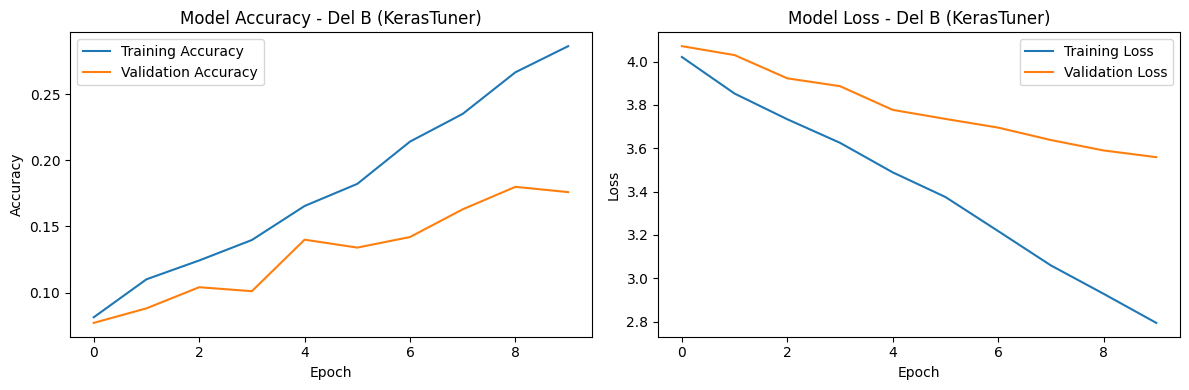

In [11]:
# Utvärdera bästa modellen på testdata
y_pred_b = best_model_b.predict(x_test, verbose=2)
y_pred_labels_b = np.argmax(y_pred_b, axis=1)
accuracy_b = np.mean(y_pred_labels_b == y_test.flatten())

print(f"\nAccuracy på testdata (Del B - KerasTuner): {accuracy_b:.4f}")
print(f"Förbättring jämfört med Del A: {accuracy_b - accuracy_a:.4f}")

# Visualisera träningshistorik
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_b.history['accuracy'], label='Training Accuracy')
plt.plot(history_b.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy - Del B (KerasTuner)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_b.history['loss'], label='Training Loss')
plt.plot(history_b.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss - Del B (KerasTuner)')
plt.legend()

plt.tight_layout()
plt.show()

# Del C: Transfer Learning

Vi använder en förtränad modell (MobileNetV2) och anpassar den för CIFAR-100 genom transfer learning.

In [12]:
# För transfer learning behöver vi ändra bildstorleken
# MobileNetV2 förväntar sig större bilder (minst 32x32, men 128x128 är bättre)
# Vi använder TensorFlow för att ändra storlek
x_train_resized = tf.image.resize(x_train, (128, 128))
x_test_resized = tf.image.resize(x_test, (128, 128))

print(f"Ny träningsdata shape: {x_train_resized.shape}")
print(f"Ny testdata shape: {x_test_resized.shape}")

Ny träningsdata shape: (5000, 128, 128, 3)
Ny testdata shape: (5000, 128, 128, 3)


In [13]:
# Ladda MobileNetV2 som base model
# include_top=False betyder att vi exkluderar output-lagret
# Vi vill lägga till vårt eget output-lager för 100 klasser
base_model = MobileNetV2(
    weights='imagenet',  # Använd vikter tränade på ImageNet
    include_top=False,  # Exkludera output-lagret
    input_shape=(128, 128, 3)  # Input-storlek
)

# Frysa vikterna i base model (vi tränar inte om dessa)
base_model.trainable = False

# Alternativt: om vi vill träna om de sista lagren, kan vi göra:
# for layer in base_model.layers[-10:]:
#     layer.trainable = True

print("Förtränad MobileNetV2 modell laddad!")
print(f"Antal lager i base model: {len(base_model.layers)}")

Förtränad MobileNetV2 modell laddad!
Antal lager i base model: 154


In [14]:
# Bygg modell med transfer learning
model_c = Sequential([
    base_model,  # Förtränad base model
    Flatten(),  # Konvertera till 1D
    Dense(100, activation='softmax')  # Output layer för 100 klasser
])

# Kompilera modellen
model_c.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Visa modellstruktur
model_c.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20480)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │     2,048,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,306,084 (16.43 MB)

 Trainable params: 2,048,100 (7.81 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# Träna modellen
# Vi tränar endast de nya lagren (Flatten och Dense)
# Base model-vikterna är frysta
history_c = model_c.fit(
    x_train_resized, y_train,
    epochs=5,  # Färre epoker eftersom vi använder förtränade vikter
    batch_size=128,
    validation_split=0.2,
    verbose=2
)

Epoch 1/5
32/32 - 13s - 414ms/step - accuracy: 0.2068 - loss: 7.2888 - val_accuracy: 0.3130 - val_loss: 4.8857
Epoch 2/5
32/32 - 8s - 257ms/step - accuracy: 0.7197 - loss: 1.2570 - val_accuracy: 0.3830 - val_loss: 3.8038
Epoch 3/5
32/32 - 8s - 259ms/step - accuracy: 0.9043 - loss: 0.3522 - val_accuracy: 0.3760 - val_loss: 3.7074
Epoch 4/5
32/32 - 8s - 251ms/step - accuracy: 0.9737 - loss: 0.1049 - val_accuracy: 0.3880 - val_loss: 3.6605
Epoch 5/5
32/32 - 8s - 254ms/step - accuracy: 0.9973 - loss: 0.0255 - val_accuracy: 0.3830 - val_loss: 3.5826


157/157 - 12s - 74ms/step

Accuracy på testdata (Del C - Transfer Learning): 0.4218
Förbättring jämfört med Del A: 0.2774


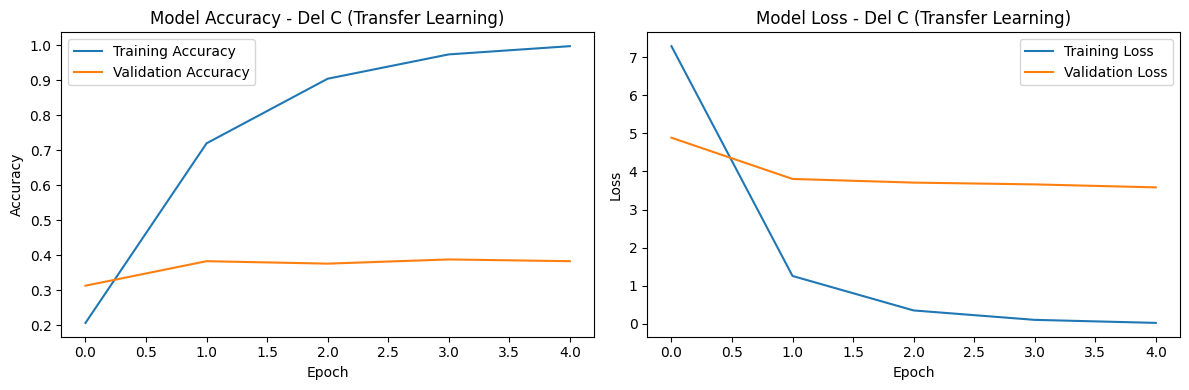

In [16]:
# Utvärdera modellen på testdata
y_pred_c = model_c.predict(x_test_resized, verbose=2)
y_pred_labels_c = np.argmax(y_pred_c, axis=1)
accuracy_c = np.mean(y_pred_labels_c == y_test.flatten())

print(f"\nAccuracy på testdata (Del C - Transfer Learning): {accuracy_c:.4f}")
print(f"Förbättring jämfört med Del A: {accuracy_c - accuracy_a:.4f}")

# Visualisera träningshistorik
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_c.history['accuracy'], label='Training Accuracy')
plt.plot(history_c.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy - Del C (Transfer Learning)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_c.history['loss'], label='Training Loss')
plt.plot(history_c.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss - Del C (Transfer Learning)')
plt.legend()

plt.tight_layout()
plt.show()

# Jämförelse av resultat


JÄMFÖRELSE AV RESULTAT
Del A (Baseline CNN): 0.1444
Del B (KerasTuner): 0.1808
Del C (Transfer Learning): 0.4218


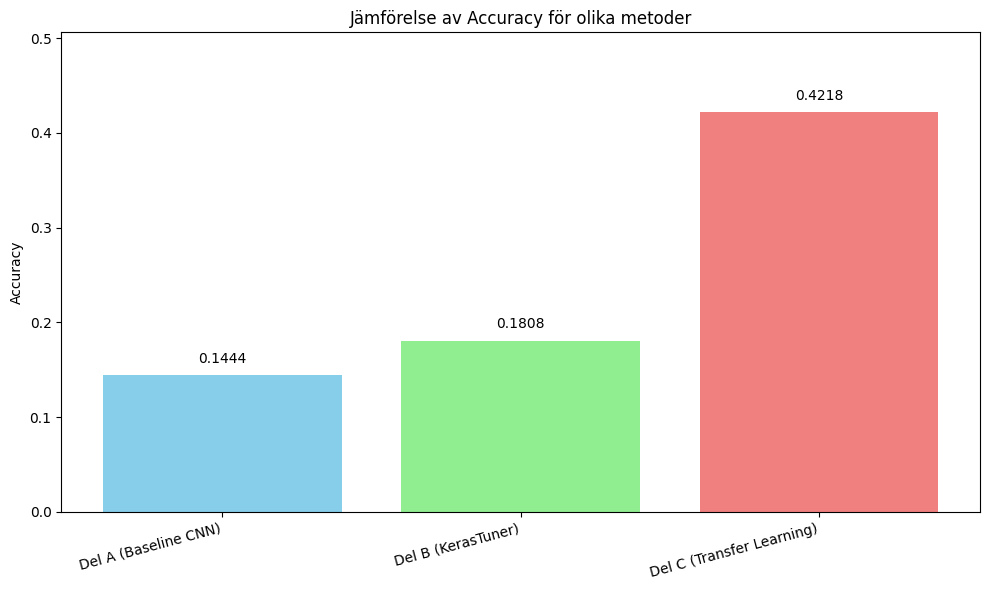


ANALYS
KerasTuner förbättrade resultatet med 0.0364
Transfer Learning förbättrade resultatet med 0.2774

Bästa metoden: Del C (Transfer Learning) med accuracy 0.4218


In [17]:
# Jämför resultaten från alla tre delar
results = {
    'Del A (Baseline CNN)': accuracy_a,
    'Del B (KerasTuner)': accuracy_b,
    'Del C (Transfer Learning)': accuracy_c
}

print("\n" + "="*50)
print("JÄMFÖRELSE AV RESULTAT")
print("="*50)
for method, acc in results.items():
    print(f"{method}: {acc:.4f}")

# Visualisera jämförelse
plt.figure(figsize=(10, 6))
methods = list(results.keys())
accuracies = list(results.values())

bars = plt.bar(methods, accuracies, color=['skyblue', 'lightgreen', 'lightcoral'])
plt.ylabel('Accuracy')
plt.title('Jämförelse av Accuracy för olika metoder')
plt.ylim([0, max(accuracies) * 1.2])

# Lägg till värden på staplarna
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.4f}', ha='center', va='bottom')

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Analysera resultat
print("\n" + "="*50)
print("ANALYS")
print("="*50)
if accuracy_b > accuracy_a:
    print(f"KerasTuner förbättrade resultatet med {accuracy_b - accuracy_a:.4f}")
else:
    print(f"KerasTuner försämrade resultatet med {accuracy_a - accuracy_b:.4f}")
    print("Detta kan bero på att max_trials var för lågt eller att träningen behöver fler epoker.")

if accuracy_c > accuracy_a:
    print(f"Transfer Learning förbättrade resultatet med {accuracy_c - accuracy_a:.4f}")
else:
    print(f"Transfer Learning försämrade resultatet med {accuracy_a - accuracy_c:.4f}")

best_method = max(results, key=results.get)
print(f"\nBästa metoden: {best_method} med accuracy {results[best_method]:.4f}")

# Sammanfattning och reflektioner

## Vad har vi lärt oss?

1. **Baseline CNN (Del A)**: Vi byggde en CNN-modell från grunden med Conv2D och MaxPooling2D lager.

2. **Hyperparameteroptimering (Del B)**: Vi använde KerasTuner för att automatiskt hitta bästa hyperparametrarna. Detta kan förbättra resultatet, men kräver mer beräkningstid.

3. **Transfer Learning (Del C)**: Vi använde en förtränad modell (MobileNetV2) och anpassade den för vår specifika uppgift. Detta är ofta mycket effektivt och ger bra resultat med mindre träning.

## Tips för förbättring:

- Använd hela CIFAR-100 datasetet (ta bort `limit` variabeln)
- Öka antalet epoker för träning
- Öka `max_trials` i KerasTuner för bättre hyperparameteroptimering
- Experimentera med olika förtränade modeller (ResNet50, VGG16, etc.)
- Använd data augmentation för att öka storleken på träningsdatan
- Prova att träna om de sista lagren i förtränade modeller (fine-tuning)

## Ytterligare läsning:

- Keras dokumentation: https://keras.io/
- KerasTuner dokumentation: https://keras.io/guides/keras_tuner/
- Transfer Learning guide: https://keras.io/guides/transfer_learning/